In [1]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt

#Coupling Class for both Complex and Power Coupling

This class incorporates both complex coupling as well as power coupling, since both of them use the same variables and parameters (thanks to some assumptions that I have made, as described in the report), with the only difference being in their differential equations that govern how the r and phase parameters for each oscillator change over time.

The differential equations that govern the dynamics of the first oscillator's state i.e., $z_1$'s parameters are: <br>
$\dot{r_1} = (\mu - r_1^2)r_1 + A r_2 \cos(\theta_2 - \theta_1 + \phi)
$ <br>
$\dot{\theta}_1 = \omega_1 + A \frac{r_2}{r_1} \sin(\theta_2 - \theta_1 + \phi)
$ <br><br>And for the second oscillator, $z_2$: <br>
$\dot{r_2} = (\mu - r_2^2)r_2 + A r_1 \cos(\theta_1 - \theta_2 - \phi)
$ <br>
$\dot{\theta}_2 = \omega_2 + A \frac{r_1}{r_2} \sin(\theta_1 - \theta_2 - \phi)
$ <br><br>
These are further described in my report.

Similarly, the differential equations that govern the dynamics of the second oscillator's state i.e., $z_2$'s parameters are: <br>
$\dot{r_1} = (\mu - r_1^2)r_1 + A_{12}  r_2^{\frac{\omega_1}{\omega_2}} \cos \left( \omega_1\left( \frac{\theta_2}{\omega_2} - \frac{\theta_1}{\omega_1} + \frac{\phi_{12}}{\omega_1 \omega_2} \right) \right)
$ <br>
$\dot{\theta}_1 = \omega_1 + A_{12} \frac{r_2^{\frac{\omega_1}{\omega_2}}}{r_1} \sin \left( \omega_1 \left( \frac{\theta_2}{\omega_2} - \frac{\theta_1}{\omega_1} + \frac{\phi_{12}}{\omega_1 \omega_2} \right) \right)
$<br><br>And for the second oscillator, $z_2$: <br>
$\dot{r_2} = (\mu - r_2^2)r_2 + A_{21}  r_2^{\frac{\omega_2}{\omega_1}} \cos \left( \omega_2\left( \frac{\theta_1}{\omega_1} - \frac{\theta_2}{\omega_2} + \frac{\phi_{21}}{\omega_1 \omega_2} \right) \right)
$ <br>
$\dot{\theta}_2 = \omega_2 + A_{21} \frac{r_1^{\frac{\omega_2}{\omega_1}}}{r_2} \sin \left( \omega_2 \left( \frac{\theta_1}{\omega_1} - \frac{\theta_2}{\omega_2} + \frac{\phi_{21}}{\omega_1 \omega_2} \right) \right)
$

These equations are implemented in the forward integration methods of the below class. Note that it can take any of the parameters as inputs, but since the question gives only 3 of them, I've initialized the other parameters randomly.

In [2]:
class Coupling_Class():
    def __init__(self, coupling_type, ω1, ω2, φ, μ = None, r1 = None, r2 = None, θ1 = None, θ2 = None, A = None, dt = 0.1, iter = 10000):
        self.coupling_type = coupling_type

        #Parameters that are given by the question:
        self.ω1 = ω1
        self.ω2 = ω2
        self.φ = φ #Assuming that φ12 = φ = -φ21

        #The other parameters, which are chosen randomly if not given:
        self.μ = random.randint(1,10) if μ == None else μ #Taking it to be 1 for simplicity
        self.r1 = random.random() if r1 == None else r1
        self.r2 = random.random() if r2 == None else r2
        self.θ1 = random.randint(-180, 180) if θ1 == None else θ1
        self.θ2 = random.randint(-180, 180) if θ2 == None else θ2
        self.A = 0.2 if A == None else A #Assuming A21 = A12 = A. This low value for A ensures that the parameters don't reach 0 immediately.

        self.dt = dt #Time step variable
        self.iter = iter #Number of iterations
        #Note that total time = iter * dt

        #The following variables keep track of the system variables as they are updated over the iterations, so that they can be used for plotting later.
        self.r1_hist = []
        self.r2_hist = []
        self.θ1_hist = []
        self.θ2_hist = []
        #The difference between these phases will converge to the value of φ, the angular component of the coupling coefficient, at steady state, as we will see below.

    def forward_integration(self):
        μ = self.μ
        A = self.A
        φ = self.φ
        ω1 = self.ω1
        ω2 = self.ω2

        dt = self.dt
        iter = self.iter

        #forward euler integration method, to calculate the parameter values over time:
        for i in range(iter):
            #Update calculations, according to the formulae shown above:
            if self.coupling_type == 'Complex':
                dr1 = (μ - (self.r1)**2) * self.r1 + A * self.r2 * np.cos(math.radians(self.θ2 - self.θ1 + φ))
                dθ1 = ω1 + A * (self.r2/self.r1) * np.sin(math.radians(self.θ2 - self.θ1 + φ))

                dr2 = (μ - (self.r2)**2) * self.r2 + A * self.r1 * np.cos(math.radians(self.θ1 - self.θ2 - φ))
                dθ2 = ω2 + A * (self.r1/self.r2) * np.sin(math.radians(self.θ1 - self.θ2 - φ))

            elif self.coupling_type == 'Power':
                dr1 = (μ - (self.r1)**2) * self.r1 + (A * (self.r2)**(ω1/ω2)) * np.cos(ω1 * math.radians((self.θ2/ω2 - self.θ1/ω1 + (φ/(ω1*ω2)))))
                dθ1 = ω1 + (A * ((self.r2)**(ω1/ω2))/self.r1) * np.sin(ω1 * math.radians((self.θ2/ω2 - self.θ1/ω1 + (φ/(ω1*ω2)))))

                dr2 = (μ - (self.r2)**2) * self.r2 + (A * (self.r1)**(ω2/ω1)) * np.cos(ω2 * math.radians((self.θ1/ω1 - self.θ2/ω2 - (φ/(ω1*ω2)))))
                dθ2 = ω2 + (A * ((self.r1)**(ω2/ω1))/self.r2) * np.sin(ω2 * math.radians((self.θ1/ω1 - self.θ2/ω2 - (φ/(ω1*ω2)))))

            #Updating the parameters and storing them in their respective history arrays:
            self.r1 += dr1 * dt
            self.θ1 += dθ1 * dt

            self.r2 += dr2 * dt
            self.θ2 += dθ2 * dt

            self.r1_hist.append(self.r1)
            self.r2_hist.append(self.r2)
            self.θ1_hist.append(self.θ1)
            self.θ2_hist.append(self.θ2)

        return self.r1_hist, self.r2_hist, self.θ1_hist, self.θ2_hist

#Plotter Functions

These are two general plotting functions I've made to streamline the process of plotting the required graphs for both types of coupling.

This first plotter function is used to plot the response i.e., the state of the oscillators over time.

In [3]:
def response_plotter(ω1, ω2, φ, coupling_type):
    model = Coupling_Class(coupling_type, ω1, ω2, φ)
    r1_hist, r2_hist, θ1_hist, θ2_hist = model.forward_integration()

    #Since we have to plot the real part of the oscillator's complex state z, we use real(z) = real(r(cosθ + isinθ)) = rcosθ
    z1_real_values = r1_hist * np.cos(np.radians(θ1_hist)) #np.cos conveniently calculates the cos of each element of the phase history arrays; np.radians works similarly as well.
    z2_real_values = r2_hist * np.cos(np.radians(θ2_hist))

    t = list(np.linspace(0, 10000, 10000)) #This creates an evenly-spaced array with a total of 10000 units, since that is the default number of iterations for our model.
    plt.figure(figsize=(16, 6))
    plt.title(f"Oscillator Response for {coupling_type} Coupling with ω1 = {ω1}, ω2 = {ω2}, φ = {φ}°")
    plt.plot(t, z1_real_values)
    plt.plot(t, z2_real_values)

    plt.legend(['Oscillator 1', 'Oscillator 2'])
    plt.ylabel("real(z)")
    plt.xlabel("Time (0.1 s)") #Since we've taken dt as 0.1 seconds in the model above.

    plt.show()

This second plotter function plots the phase difference (in the case of complex coupling) or normalized phase difference (for power coupling) between the two coupled oscillators over time. To show that these values converge to a constant in both complex (where it converges to φ) and power (where it converges to φ/ω1ω2) coupling at steady state irrespective of the starting point, I've plotted several trials each of which have different, random starting points for the other parameters. That constant value is demarcated by a horizontal dashed line.

In [4]:
def phase_diff_plotter(ω1, ω2, φ, coupling_type):
    colors = ['y', 'g', 'c', 'm', 'k'] * 2
    for trial in range(10):
        model = Coupling_Class(coupling_type, ω1, ω2, φ)
        r1_hist, r2_hist, θ1_hist, θ2_hist = model.forward_integration()

        if coupling_type == 'Complex':
            ψ = np.subtract(θ1_hist, θ2_hist) #This is the phase difference between the oscillators.
        elif coupling_type == 'Power':
            ψ = np.subtract([θ1/ω1 for θ1 in θ1_hist], [θ2/ω2 for θ2 in θ2_hist]) #This is the normalized phase difference between the oscillators.

        t = list(np.linspace(0, 10000, 10000))
        plt.plot(t, ψ, color = colors[trial])

    SS_value = φ if coupling_type == 'Complex' else φ/(ω1 * ω2)
    plt.axhline(SS_value, linestyle="dashed") #To mark the value which ψ will converge to at steady state.
    plt.title(f"{'Normalized ' if coupling_type == 'Power' else ''}Phase Difference between Oscillators for {coupling_type} Coupling with ω1 = {ω1}, ω2 = {ω2}, φ = {φ}°")
    plt.ylabel(f"{'Normalized ' if coupling_type == 'Power' else ''}Phase Difference (in degrees)")
    plt.xlabel("Time (0.1 s)")
    plt.ylim(SS_value - 5, SS_value + 5)
    plt.figure(figsize=(10, 6))
    plt.show()

#Complex Coupling

Given parameters:

In [5]:
ω1 = ω2 = 5
φ1 = -47
φ2 = 98

##Complex coupling with a phase difference of -47 degrees:

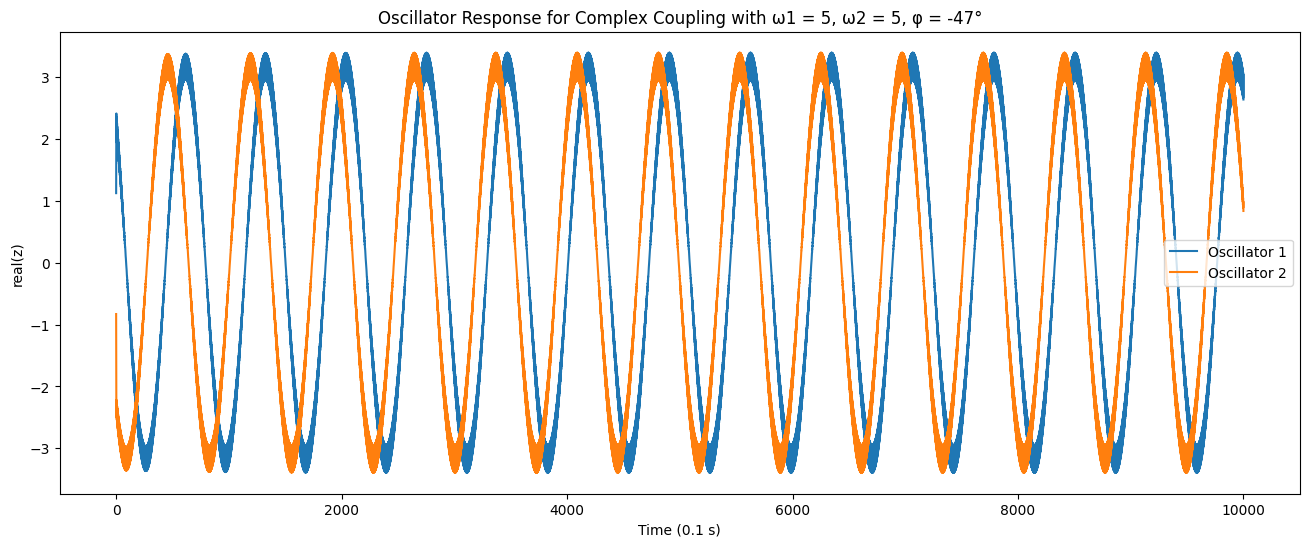

In [6]:
response_plotter(ω1, ω2, φ1, 'Complex')

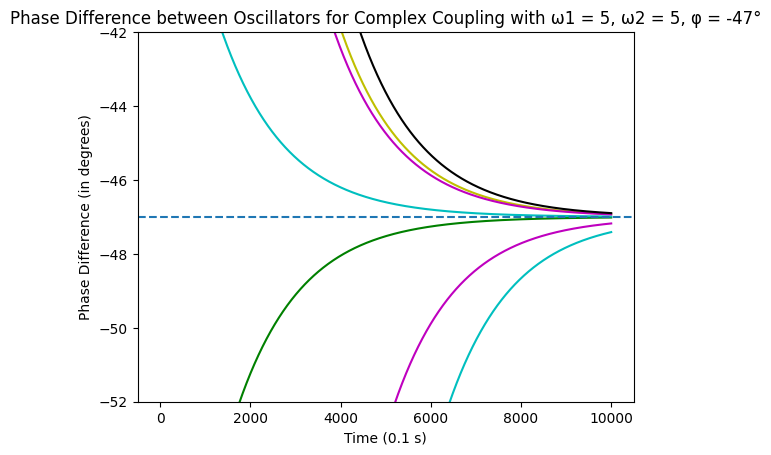

<Figure size 1000x600 with 0 Axes>

In [7]:
phase_diff_plotter(ω1, ω2, φ1, 'Complex')

##Complex coupling with a phase difference of 98 degrees:

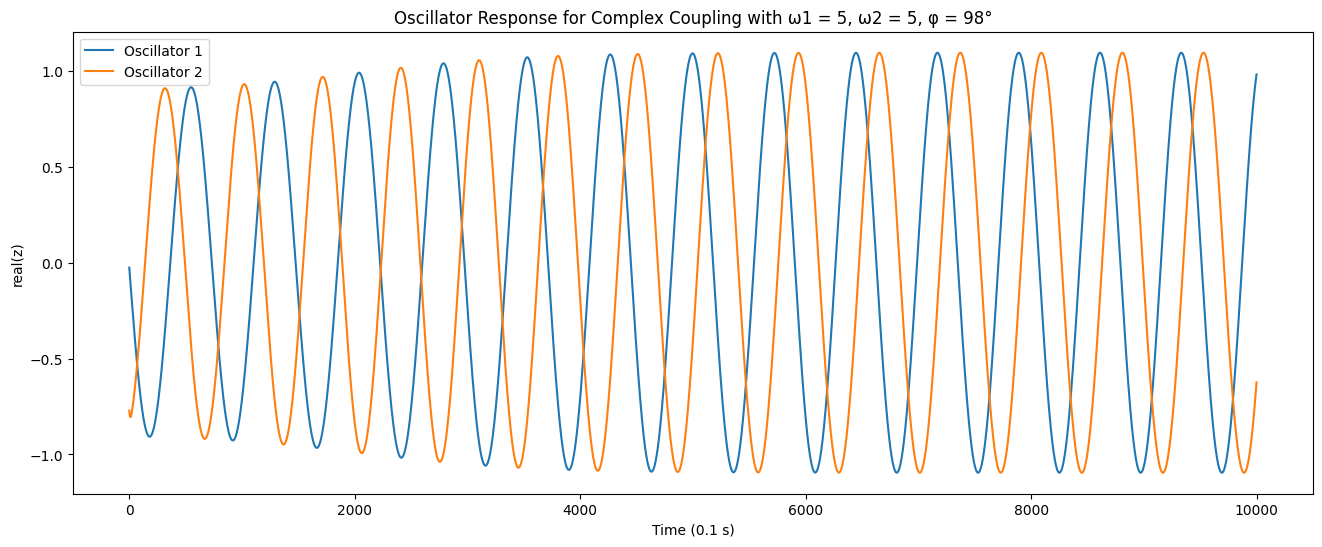

In [8]:
response_plotter(ω1, ω2, φ2, 'Complex')

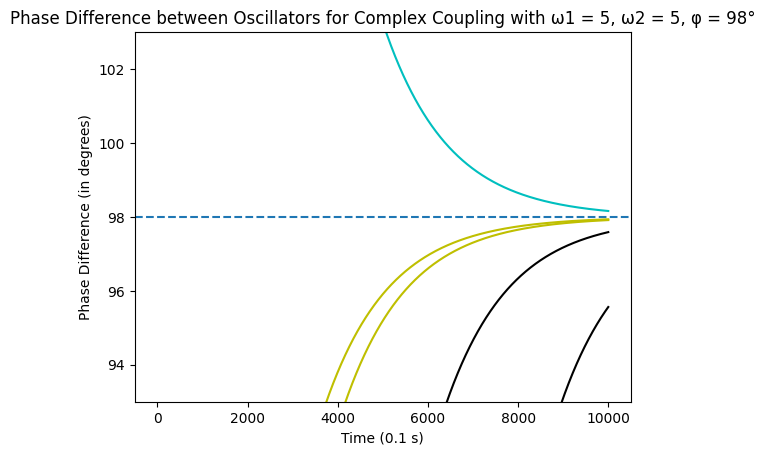

<Figure size 1000x600 with 0 Axes>

In [9]:
phase_diff_plotter(ω1, ω2, φ2, 'Complex')

#Power Coupling

Given parameters:

In [10]:
ω1 = 5
ω2 = 15
φ1 = -47
φ2 = 98

##Power coupling with a phase difference of -47 degrees:

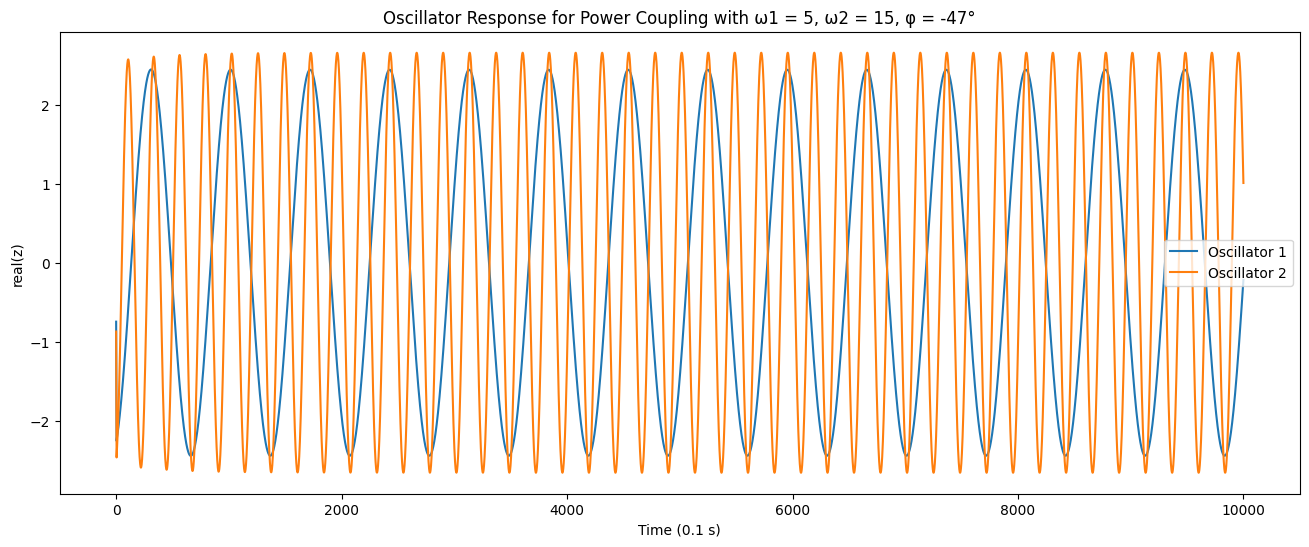

In [11]:
response_plotter(ω1, ω2, φ1, 'Power')

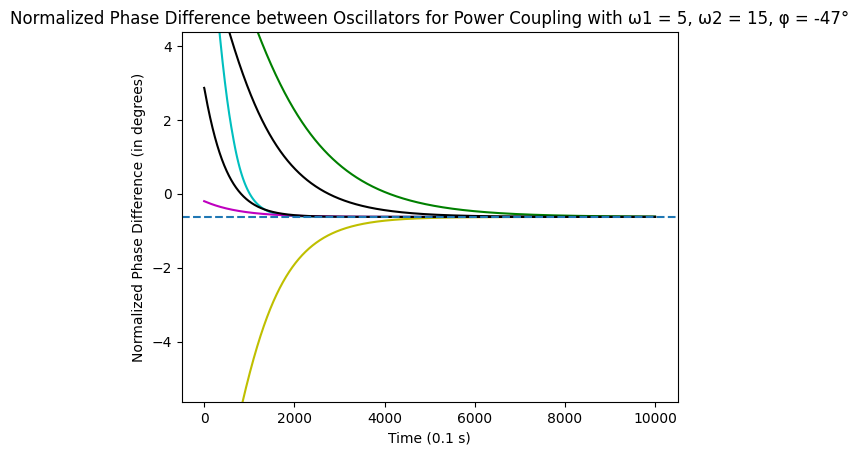

<Figure size 1000x600 with 0 Axes>

In [12]:
phase_diff_plotter(ω1, ω2, φ1, 'Power')

##Power coupling with a phase difference of 98 degrees:

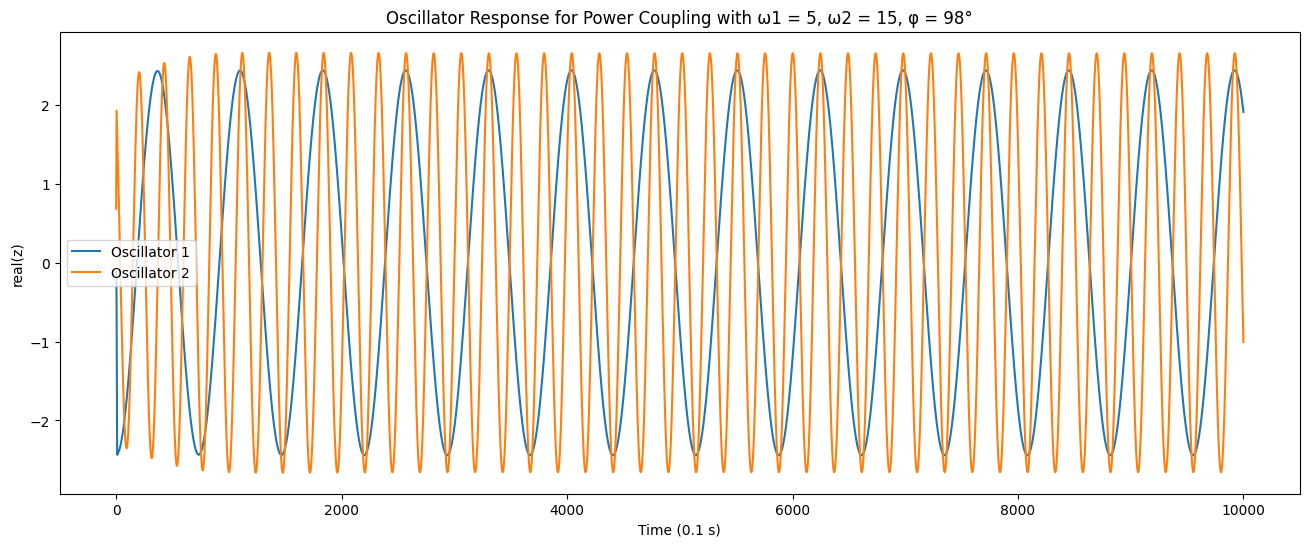

In [13]:
response_plotter(ω1, ω2, φ2, 'Power')

C:\Users\shiva\AppData\Local\Temp\ipykernel_12572\1385459019.py:50: RuntimeWarning: invalid value encountered in scalar power
  dr1 = (μ - (self.r1)**2) * self.r1 + (A * (self.r2)**(ω1/ω2)) * np.cos(ω1 * math.radians((self.θ2/ω2 - self.θ1/ω1 + (φ/(ω1*ω2)))))
C:\Users\shiva\AppData\Local\Temp\ipykernel_12572\1385459019.py:51: RuntimeWarning: invalid value encountered in scalar power
  dθ1 = ω1 + (A * ((self.r2)**(ω1/ω2))/self.r1) * np.sin(ω1 * math.radians((self.θ2/ω2 - self.θ1/ω1 + (φ/(ω1*ω2)))))


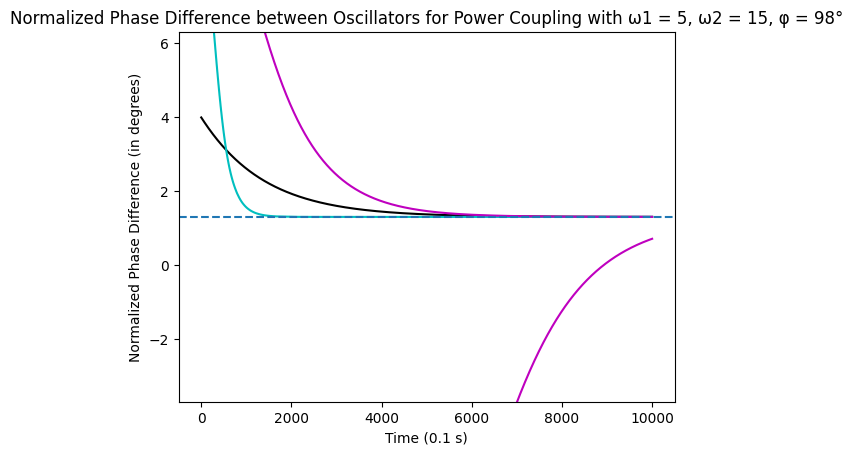

<Figure size 1000x600 with 0 Axes>

In [14]:
phase_diff_plotter(ω1, ω2, φ2, 'Power')